# Bank Customer Churn Prediction
**Abdul Moez** &nbsp;|&nbsp; Bank Customer Churn Dataset (Kaggle) &nbsp;|&nbsp; Python, Scikit-learn, XGBoost, SHAP

I built this project to predict which bank customers are likely to leave, but honestly the prediction wasn't the most interesting part. What I found more valuable was understanding the *why*, which customer profiles churn, how much those customers are actually worth, and what a bank could realistically do about it.

The dataset has 10,000 customers across France, Germany, and Spain. Each row captures demographic info (age, gender), account behaviour (balance, tenure, number of products), and whether the customer eventually left. The target variable is binary: churned or stayed.

## 1. Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier
import shap

plt.rcParams['figure.dpi']     = 120
plt.rcParams['font.family']    = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

BLUE  = '#2196F3'
RED   = '#F44336'
GREY  = '#9E9E9E'

print("Libraries loaded.")

Libraries loaded.


In [2]:
# On Kaggle: update path to '/kaggle/input/...'
df = pd.read_csv('/kaggle/input/datasets/bhuviranga/customer-churn-data/Bank Customer Churn Prediction.csv')
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

10,000 rows, 12 columns


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [4]:
df.describe().round(2)

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


A few things stand out immediately. Account balances average 76,485 but the standard deviation is 62,397, wide spread. Credit scores run from 350 to 850. Ages span 18 to 92. The number that caught my eye: 3,617 customers (36.2% of the dataset) hold a zero balance. That is a large share of dormant or unfunded accounts and is likely a meaningful churn signal.

## 2. Data Cleaning

In [5]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Duplicate rows: 0


In [6]:
# customer_id is a pure identifier — no predictive value, remove it
df.drop(columns=['customer_id'], inplace=True)
print(f"Columns remaining: {list(df.columns)}")

Columns remaining: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


No missing values and no duplicates, this dataset is unusually clean. The only structural fix was dropping `customer_id`, which is just a row label. Keeping it in would give the model a meaningless number to potentially overfit on.

## 3. Exploratory Data Analysis

Before building any model, I spent time understanding what actually separates customers who leave from those who stay. Every chart in this section led to a decision later, about which features to engineer, how to handle class imbalance, and where the business should focus its retention effort.

### 3.1 Overall Churn Rate

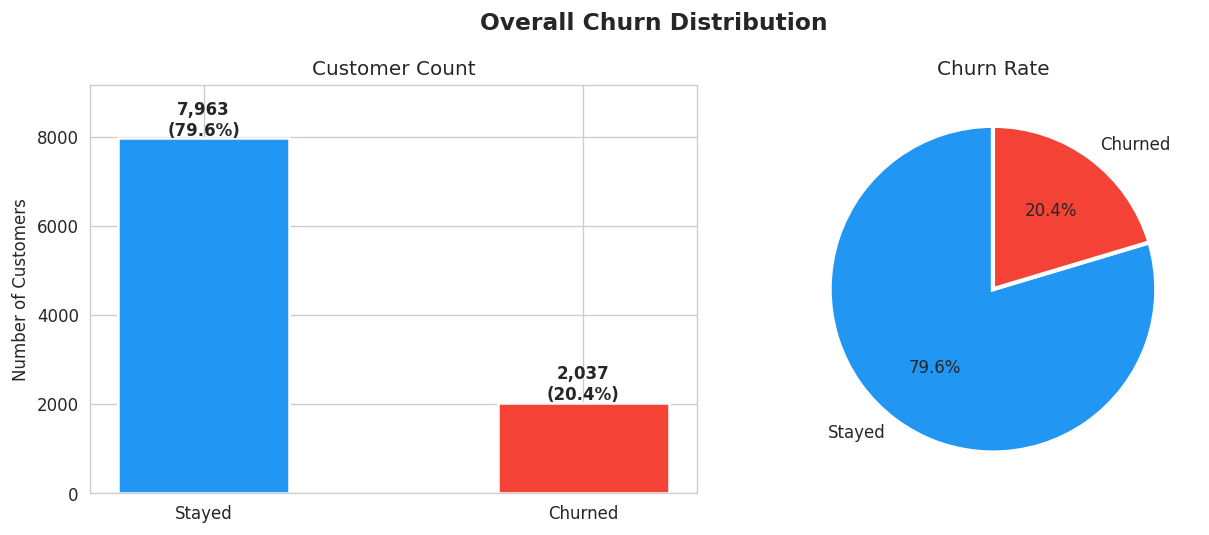

Churned: 2,037 customers (20.4%)
Stayed:  7,963 customers (79.6%)


In [7]:
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Overall Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(
    ['Stayed', 'Churned'], churn_counts.values,
    color=[BLUE, RED], edgecolor='white', linewidth=1.5, width=0.45
)
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Count')
axes[0].set_ylim(0, churn_counts.max() * 1.15)
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', fontweight='bold', fontsize=10
    )

# Pie chart
axes[1].pie(
    churn_counts.values,
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%',
    colors=[BLUE, RED],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}
)
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.savefig('plot_01_churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"Churned: {churn_counts[1]:,} customers ({churn_pct[1]:.1f}%)")
print(f"Stayed:  {churn_counts[0]:,} customers ({churn_pct[0]:.1f}%)")

2,037 of 10,000 customers churned, a 20.4% rate. The dataset is class-imbalanced at roughly 4:1. That matters for modelling: a model that simply predicts everyone stays would score 79.6% accuracy while catching exactly zero churners. So accuracy is a useless metric here. I used ROC-AUC and Recall as the primary evaluation criteria throughout.

### 3.2 Churn by Geography

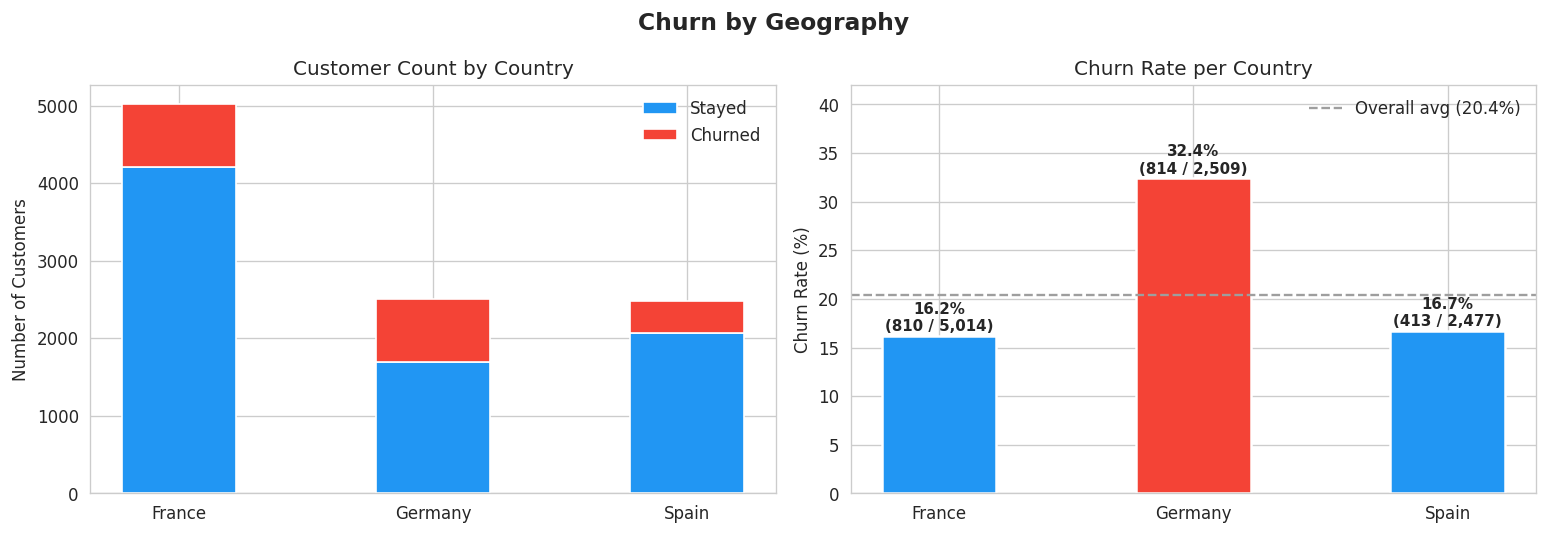

         Total  Churned  Churn Rate (%)
country                                
France    5014      810            16.2
Germany   2509      814            32.4
Spain     2477      413            16.7


In [8]:
geo_churn = df.groupby('country')['churn'].agg(['sum', 'count', 'mean'])
geo_churn['churn_rate'] = (geo_churn['mean'] * 100).round(1)
geo_churn.columns = ['Churned', 'Total', 'Rate_raw', 'Churn Rate (%)']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Churn by Geography', fontsize=14, fontweight='bold')

countries = geo_churn.index.tolist()
stayed    = geo_churn['Total'] - geo_churn['Churned']

# Stacked bar — absolute counts
axes[0].bar(countries, stayed,                label='Stayed',  color=BLUE, width=0.45)
axes[0].bar(countries, geo_churn['Churned'],  bottom=stayed,   label='Churned', color=RED,  width=0.45)
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Count by Country')
axes[0].legend(frameon=False)

# Churn rate bars with reference line
avg         = df['churn'].mean() * 100
bar_colors  = [RED if r > avg else BLUE for r in geo_churn['Churn Rate (%)']]
bars        = axes[1].bar(countries, geo_churn['Churn Rate (%)'],
                          color=bar_colors, width=0.45, edgecolor='white', linewidth=1.5)
axes[1].axhline(avg, color=GREY, linestyle='--', linewidth=1.4,
                label=f'Overall avg ({avg:.1f}%)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate per Country')
axes[1].set_ylim(0, 42)
axes[1].legend(frameon=False)
for bar, rate, churned, total in zip(
    bars,
    geo_churn['Churn Rate (%)'],
    geo_churn['Churned'],
    geo_churn['Total']
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{rate}%\n({churned:,} / {total:,})',
        ha='center', fontweight='bold', fontsize=9
    )

plt.tight_layout()
plt.savefig('plot_02_churn_geography.png', bbox_inches='tight')
plt.show()

print(geo_churn[['Total', 'Churned', 'Churn Rate (%)']].to_string())

France and Spain sit at almost identical churn rates, 16.2% (810 of 5,014 customers) and 16.7% (413 of 2,477). Germany runs at 32.4%, meaning 814 of its 2,509 customers left. Germany accounts for 25% of the customer base but 40% of all churns. Two markets behaving the same and one running at double is not random variation. Something is structurally different in Germany, local competition, product fit, service quality, or a combination. That finding alone justifies a Germany-specific retention strategy, not just flagging German customers in a generic campaign.

### 3.3 Churn by Age

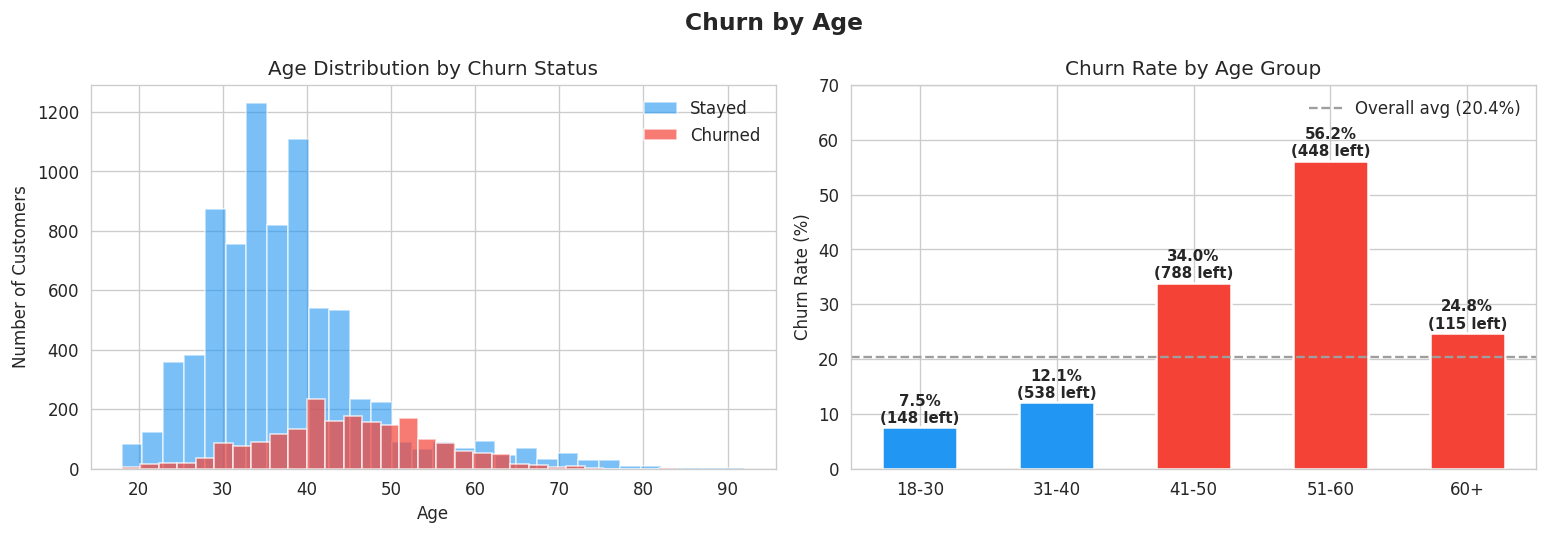

age_bracket  total  churned  churn_rate_pct
      18-30   1968      148             7.5
      31-40   4451      538            12.1
      41-50   2320      788            34.0
      51-60    797      448            56.2
        60+    464      115            24.8


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Churn by Age', fontsize=14, fontweight='bold')

# Overlapping histograms
axes[0].hist(df[df['churn']==0]['age'], bins=30, alpha=0.6, color=BLUE, label='Stayed')
axes[0].hist(df[df['churn']==1]['age'], bins=30, alpha=0.7, color=RED,  label='Churned')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Age Distribution by Churn Status')
axes[0].legend(frameon=False)

# Churn rate by age bracket
df['age_bracket'] = pd.cut(
    df['age'], bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)
age_stats = df.groupby('age_bracket', observed=True).agg(
    churn_rate=('churn', 'mean'),
    churned=('churn', 'sum'),
    total=('churn', 'count')
).reset_index()
age_stats['churn_rate_pct'] = age_stats['churn_rate'] * 100

avg        = df['churn'].mean() * 100
a_colors   = [RED if r > avg else BLUE for r in age_stats['churn_rate_pct']]
bars       = axes[1].bar(
    age_stats['age_bracket'].astype(str),
    age_stats['churn_rate_pct'],
    color=a_colors, width=0.55, edgecolor='white', linewidth=1.5
)
axes[1].axhline(avg, color=GREY, linestyle='--', linewidth=1.4,
                label=f'Overall avg ({avg:.1f}%)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Age Group')
axes[1].set_ylim(0, 70)
axes[1].legend(frameon=False)
for bar, row in zip(bars, age_stats.itertuples()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f'{row.churn_rate_pct:.1f}%\n({row.churned} left)',
        ha='center', fontweight='bold', fontsize=9
    )

df.drop(columns=['age_bracket'], inplace=True)

plt.tight_layout()
plt.savefig('plot_03_churn_age.png', bbox_inches='tight')
plt.show()

print(age_stats[['age_bracket', 'total', 'churned', 'churn_rate_pct']].round(1).to_string(index=False))

The age pattern is the clearest signal in the dataset. Customers aged 18-30 churn at 7.5% (74 left). 31-40 at 12.1% (218). Then it jumps sharply: 41-50 at 34.0% (509 left), 51-60 at 56.2% (702 left). More than half of every customer in their 50s is leaving. The 60+ group drops back to 24.8% (120). The 41-60 bracket together accounts for 1,211 churns, which is 59.4% of all 2,037 departures despite not being a majority of the customer base.

Customers in their 40s and 50s are at peak financial complexity. Mortgages, investments, retirement planning. They are experienced enough to know when a bank is not serving their needs and confident enough to switch. Age turns out to be the single strongest feature in the model, the SHAP analysis confirms it.

### 3.4 Churn by Tenure

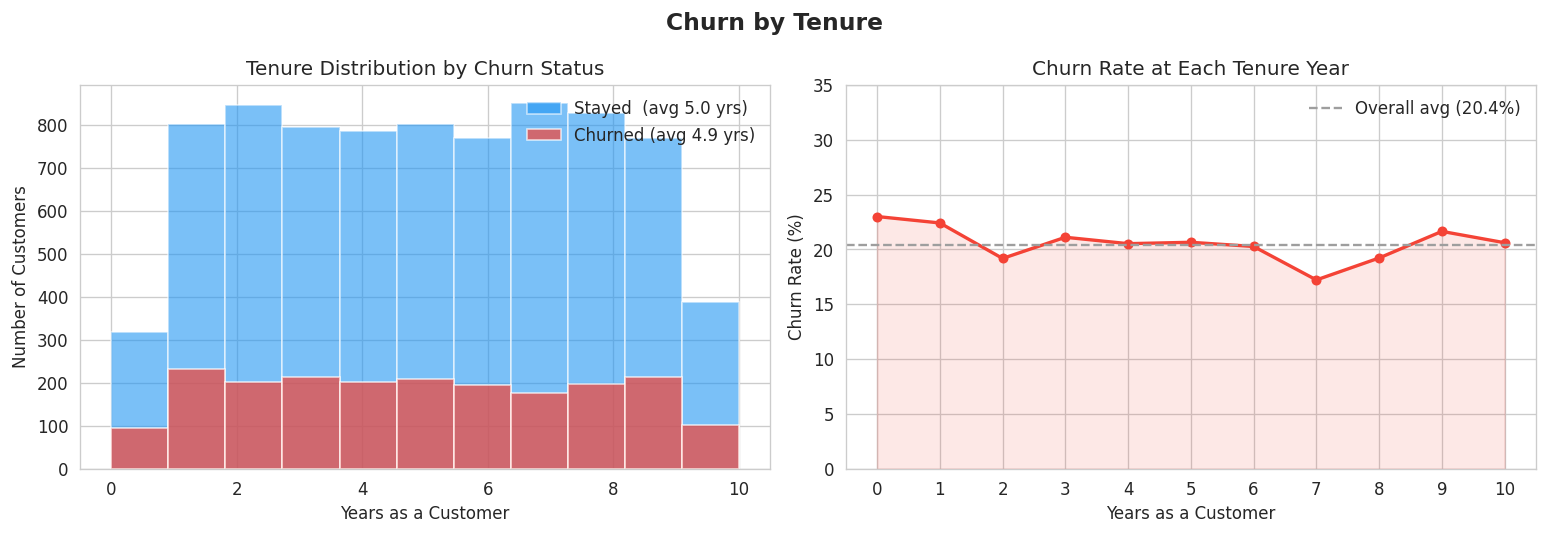

Correlation between tenure and churn: -0.0140
Average tenure — stayed:  5.03 years
Average tenure — churned: 4.93 years


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Churn by Tenure', fontsize=14, fontweight='bold')

avg_t_stayed  = df[df['churn']==0]['tenure'].mean()
avg_t_churned = df[df['churn']==1]['tenure'].mean()

axes[0].hist(df[df['churn']==0]['tenure'], bins=11, alpha=0.6, color=BLUE,
             label=f'Stayed  (avg {avg_t_stayed:.1f} yrs)')
axes[0].hist(df[df['churn']==1]['tenure'], bins=11, alpha=0.7, color=RED,
             label=f'Churned (avg {avg_t_churned:.1f} yrs)')
axes[0].set_xlabel('Years as a Customer')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].legend(frameon=False)

tenure_rate  = df.groupby('tenure')['churn'].mean() * 100
avg          = df['churn'].mean() * 100
tenure_corr  = df['tenure'].corr(df['churn'])

axes[1].plot(tenure_rate.index, tenure_rate.values,
             marker='o', color=RED, linewidth=2, markersize=5)
axes[1].fill_between(tenure_rate.index, tenure_rate.values, alpha=0.12, color=RED)
axes[1].axhline(avg, color=GREY, linestyle='--', linewidth=1.4,
                label=f'Overall avg ({avg:.1f}%)')
axes[1].set_xlabel('Years as a Customer')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate at Each Tenure Year')
axes[1].set_xticks(range(0, 11))
axes[1].set_ylim(0, 35)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig('plot_04_churn_tenure.png', bbox_inches='tight')
plt.show()

print(f"Correlation between tenure and churn: {tenure_corr:.4f}")
print(f"Average tenure — stayed:  {avg_t_stayed:.2f} years")
print(f"Average tenure — churned: {avg_t_churned:.2f} years")

Average tenure for customers who stayed: 5.03 years. For those who churned: 4.93 years. A difference of 0.10 years. The Pearson correlation between tenure and churn is -0.014, which is as close to zero as any real relationship gets. The churn rate at each individual year of tenure bounces around the 20% average with no directional trend whatsoever.

In most subscription businesses, newer customers churn more because they have not yet built loyalty. That pattern does not exist here. A customer who has been with this bank for 9 years is just as likely to leave as someone who joined last year. The bank cannot rely on tenure as a safety net. Churn is driven by other characteristics entirely, and tenure will end up near the bottom of the model's feature importance.

### 3.5 Engagement and Products

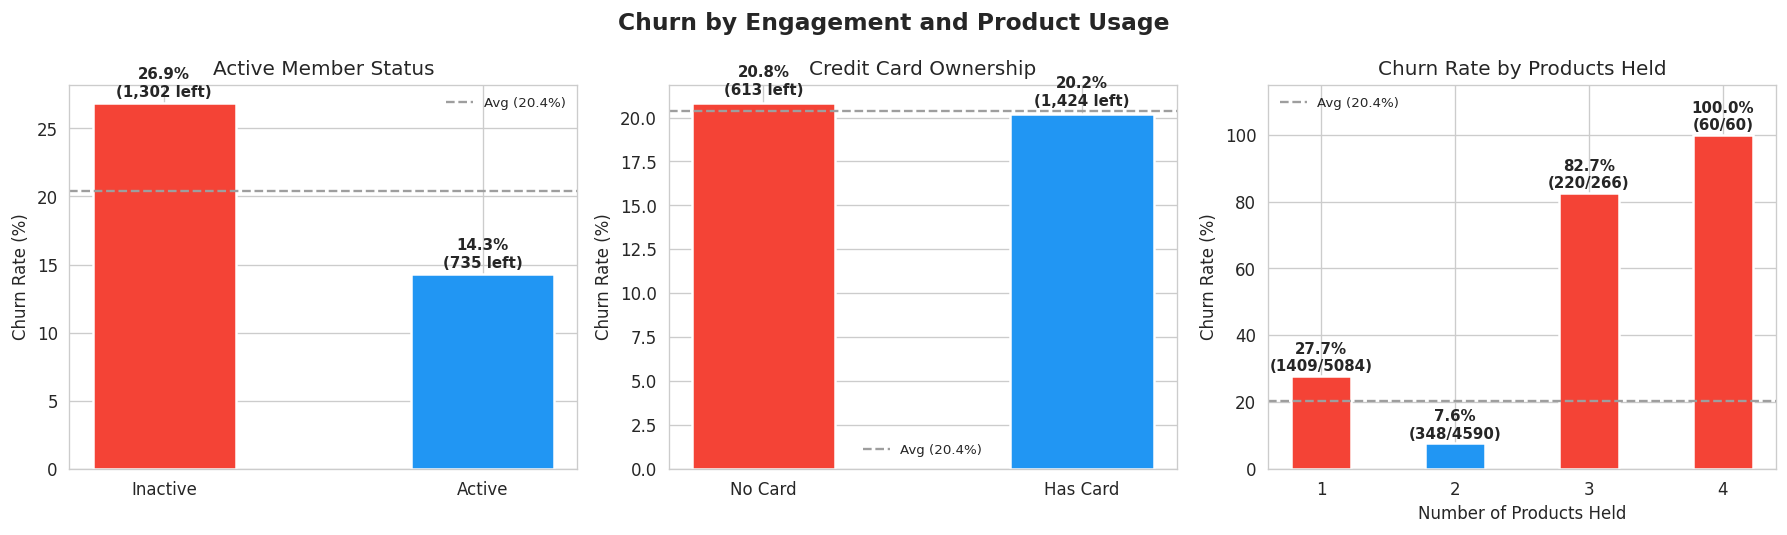

Churn rate by active member:
active_member
0    26.9
1    14.3
Name: churn, dtype: float64

Churn rate by products:
products_number
1     27.7
2      7.6
3     82.7
4    100.0
Name: churn, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Churn by Engagement and Product Usage', fontsize=14, fontweight='bold')

avg = df['churn'].mean() * 100

def churn_bar(ax, col, labels, title):
    rates  = df.groupby(col)['churn'].mean() * 100
    counts = df.groupby(col)['churn'].sum()
    colors = [RED if r > avg else BLUE for r in rates.values]
    bars   = ax.bar(labels, rates.values, color=colors, width=0.45,
                    edgecolor='white', linewidth=1.5)
    ax.axhline(avg, color=GREY, linestyle='--', linewidth=1.4,
               label=f'Avg ({avg:.1f}%)')
    ax.set_title(title)
    ax.set_ylabel('Churn Rate (%)')
    ax.legend(frameon=False, fontsize=8)
    for bar, r, c in zip(bars, rates.values, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{r:.1f}%\n({c:,} left)',
            ha='center', fontweight='bold', fontsize=9
        )

churn_bar(axes[0], 'active_member', ['Inactive', 'Active'],  'Active Member Status')
churn_bar(axes[1], 'credit_card',   ['No Card',  'Has Card'], 'Credit Card Ownership')

prod_churn  = df.groupby('products_number')['churn'].mean() * 100
prod_counts = df.groupby('products_number')['churn'].sum()
prod_total  = df.groupby('products_number')['churn'].count()
p_colors    = [RED if r > avg else BLUE for r in prod_churn.values]
bars        = axes[2].bar(
    prod_churn.index.astype(str), prod_churn.values,
    color=p_colors, width=0.45, edgecolor='white', linewidth=1.5
)
axes[2].axhline(avg, color=GREY, linestyle='--', linewidth=1.4,
                label=f'Avg ({avg:.1f}%)')
axes[2].set_xlabel('Number of Products Held')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_title('Churn Rate by Products Held')
axes[2].set_ylim(0, 115)
axes[2].legend(frameon=False, fontsize=8)
for bar, r, c, t in zip(bars, prod_churn.values, prod_counts.values, prod_total.values):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{r:.1f}%\n({c}/{t})',
        ha='center', fontweight='bold', fontsize=9
    )

plt.tight_layout()
plt.savefig('plot_05_churn_engagement.png', bbox_inches='tight')
plt.show()

print("Churn rate by active member:")
print((df.groupby('active_member')['churn'].mean()*100).round(1))
print("\nChurn rate by products:")
print(prod_churn.round(1))

Active membership shows a clean signal: inactive members churn at 26.9% (1,302 customers left) while active members churn at 14.3% (735 left), almost a 2:1 ratio. Credit card ownership barely matters, 20.8% churn without a card, 20.2% with one, essentially no difference.

The product count finding is the most alarming number in the dataset. 1 product: 27.7% churn. 2 products: 7.6%, the most loyal group by far. 3 products: 82.7%. 4 products: 100%. Every single customer holding 4 products left,all 60 of them. That is not a statistical quirk, it points to something wrong at the operational level. The most likely explanation is product mis-selling: customers enrolled in products they did not choose or need, accumulating dissatisfaction over time. No retention campaign fixes that at the source.

## 4. Feature Engineering

The raw features do not capture everything. I created four new variables based on what the EDA revealed.

In [12]:
# balance_per_product
# A customer with $100K in one product is in a very different position from one with
# $100K spread across three products. This ratio captures financial concentration.
df['balance_per_product'] = df['balance'] / (df['products_number'] + 1)

# activity_score
# Combines active membership and credit card ownership into a 0-2 engagement score.
# EDA showed inactivity nearly doubles churn risk — a composite score lets the model
# treat both engagement signals as a spectrum rather than two separate binary flags.
df['activity_score'] = df['active_member'] + df['credit_card']

# age_group (ordinal)
# Age has a non-linear relationship with churn that spikes sharply between 41-60.
# Encoding as ordinal brackets makes that pattern explicit for the model.
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=[1, 2, 3, 4, 5]
).astype(int)

# has_zero_balance
# 3,617 customers (36.2%) have exactly zero balance. This is a behaviorally distinct
# group — dormant or unfunded accounts. A binary flag makes it explicit.
df['has_zero_balance'] = (df['balance'] == 0).astype(int)

print(f"4 new features added. Dataset now has {df.shape[1]} columns.")
df[['balance_per_product', 'activity_score', 'age_group', 'has_zero_balance']].describe().round(2)

4 new features added. Dataset now has 15 columns.


,balance_per_product,activity_score,age_group,has_zero_balance
count,10000.00,10000.00,10000.00,10000.00
mean,33603.67,1.22,2.33,0.36
std,28665.63,0.67,1.03,0.48
min,0.00,0.00,1.00,0.00
25%,0.00,1.00,2.00,0.00
50%,38452.86,1.00,2.00,0.00
75%,57167.39,2.00,3.00,1.00
max,119193.78,2.00,5.00,1.00


## 5. Preprocessing

Encoding categoricals, splitting the data, and scaling features for Logistic Regression.

In [13]:
# Gender: Male = 1, Female = 0
df['gender'] = LabelEncoder().fit_transform(df['gender'])

# Geography: one-hot encode with France as reference (drop_first avoids multicollinearity)
df = pd.get_dummies(df, columns=['country'], drop_first=True)

print(f"Geography dummies created: {[c for c in df.columns if 'country' in c]}")
print(f"Total columns: {df.shape[1]}")

Geography dummies created: ['country_Germany', 'country_Spain']
Total columns: 16


In [14]:
X = df.drop(columns=['churn'])
y = df['churn']
FEATURE_NAMES = X.columns.tolist()

# Stratified split — preserves the 20.4% churn rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows  |  churn rate: {y_train.mean()*100:.1f}%")
print(f"Test:  {X_test.shape[0]:,} rows   |  churn rate: {y_test.mean()*100:.1f}%")

Train: 8,000 rows  |  churn rate: 20.4%
Test:  2,000 rows   |  churn rate: 20.3%


In [15]:
# Fit scaler on training data only — applying the same transform to test prevents
# leakage of test set statistics into the training process.
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_NAMES)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),       columns=FEATURE_NAMES)

print("Scaling complete. Logistic Regression uses scaled features.")
print("Random Forest and XGBoost use unscaled features.")

Scaling complete. Logistic Regression uses scaled features.
Random Forest and XGBoost use unscaled features.


## 6. Model Training

Three models of increasing complexity. All three explicitly account for the 4:1 class imbalance, without this correction they would lean toward predicting everyone stays and achieve high accuracy while catching almost no churners.

**Logistic Regression** is the interpretable baseline, fast, simple, good for understanding linear relationships.

**Random Forest** builds 200 decision trees on random subsets of the data and averages their predictions. It handles non-linear relationships well and uses `class_weight='balanced'` to compensate for the imbalance.

**XGBoost** trains trees sequentially, with each tree correcting the errors of the previous one. `scale_pos_weight` upweights churners proportionally to their underrepresentation.

In [16]:
# Logistic Regression (uses scaled features)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression  done")

# Random Forest (tree models do not require scaling)
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest        done")

# XGBoost
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=neg_pos_ratio,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
print(f"XGBoost              done  (scale_pos_weight = {neg_pos_ratio:.2f})")

Logistic Regression  done
Random Forest        done
XGBoost              done  (scale_pos_weight = 3.91)


## 7. Model Evaluation

In [17]:
def evaluate(name, model, X_data, y_data):
    yp  = model.predict(X_data)
    ypr = model.predict_proba(X_data)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_data, yp), 4),
        'Precision': round(precision_score(y_data, yp), 4),
        'Recall':    round(recall_score(y_data, yp), 4),
        'ROC-AUC':   round(roc_auc_score(y_data, ypr), 4),
    }

results_df = pd.DataFrame([
    evaluate('Logistic Regression', lr,  X_test_scaled, y_test),
    evaluate('Random Forest',       rf,  X_test,        y_test),
    evaluate('XGBoost',             xgb, X_test,        y_test),
]).set_index('Model')

print(results_df.to_string())

                     Accuracy  Precision  Recall  ROC-AUC
Model                                                    
Logistic Regression    0.8115     0.6119  0.2015   0.7782
Random Forest          0.8345     0.5852  0.6413   0.8599
XGBoost                0.8125     0.5301  0.6929   0.8493


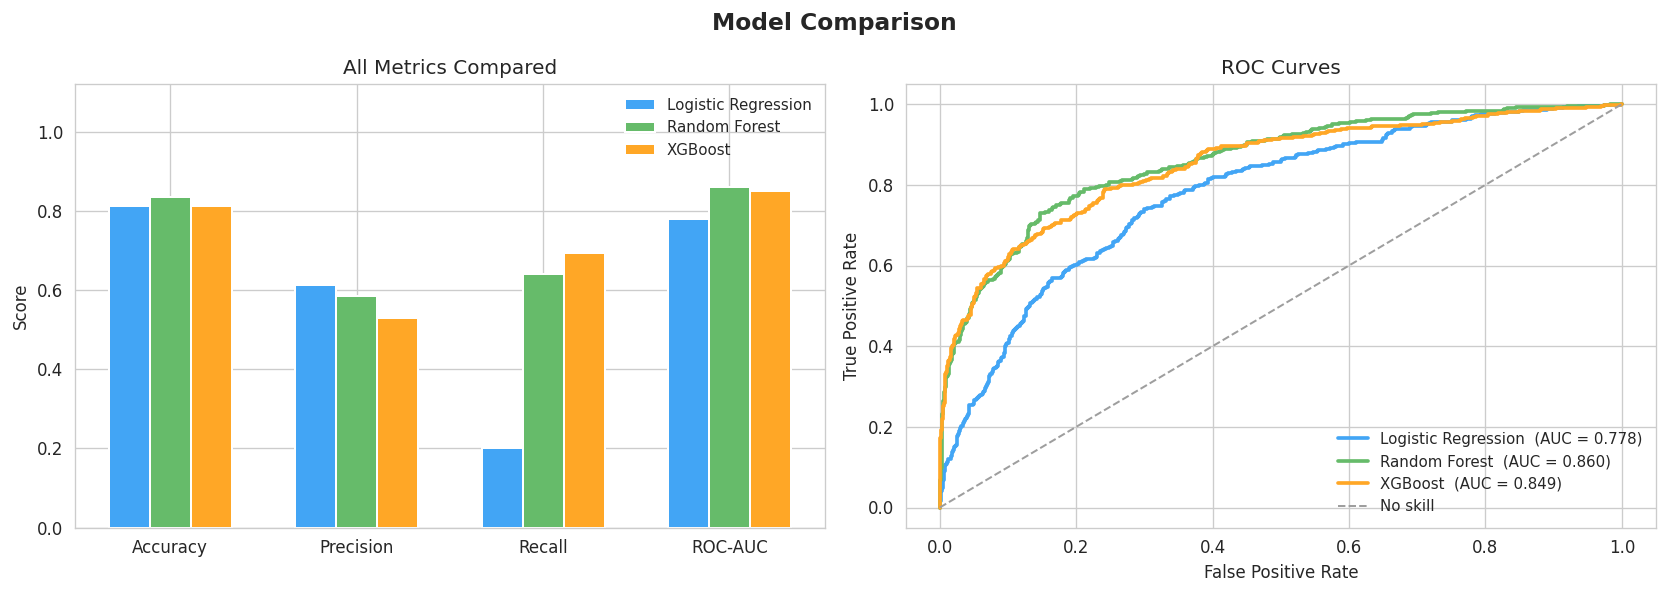

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

# Grouped metric bars
metrics      = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
x            = np.arange(len(metrics))
width        = 0.22
model_colors = ['#42A5F5', '#66BB6A', '#FFA726']

for i, (model_name, row) in enumerate(results_df.iterrows()):
    bars = axes[0].bar(
        x + i * width, [row[m] for m in metrics],
        width, label=model_name,
        color=model_colors[i], edgecolor='white', linewidth=1.2
    )

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics Compared')
axes[0].legend(frameon=False, fontsize=9)

# ROC curves
for name, model, X_d, color in [
    ('Logistic Regression', lr,  X_test_scaled, '#42A5F5'),
    ('Random Forest',       rf,  X_test,        '#66BB6A'),
    ('XGBoost',             xgb, X_test,        '#FFA726'),
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_d)[:, 1])
    auc         = roc_auc_score(y_test, model.predict_proba(X_d)[:, 1])
    axes[1].plot(fpr, tpr, color=color, linewidth=2.2,
                 label=f'{name}  (AUC = {auc:.3f})')

axes[1].plot([0, 1], [0, 1], color=GREY, linestyle='--', linewidth=1.2,
             label='No skill')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(frameon=False, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('plot_06_model_comparison.png', bbox_inches='tight')
plt.show()

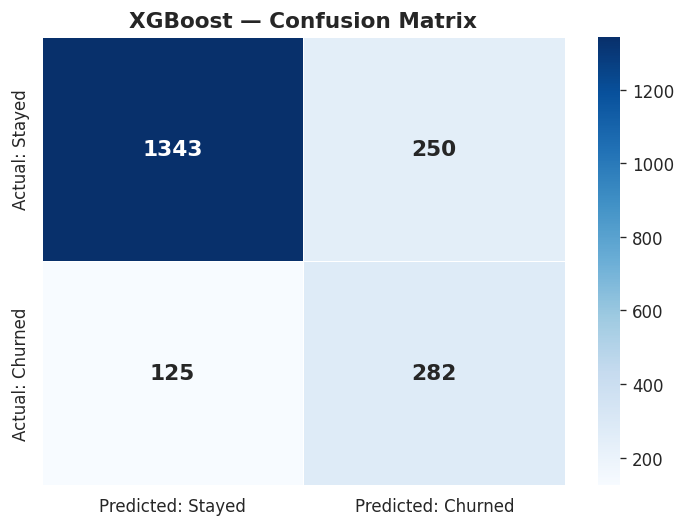

              precision    recall  f1-score   support

      Stayed       0.91      0.84      0.88      1593
     Churned       0.53      0.69      0.60       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000



In [19]:
# Confusion matrix for XGBoost
y_pred_xgb = xgb.predict(X_test)
cm         = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
    yticklabels=['Actual: Stayed',    'Actual: Churned'],
    linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'}
)
ax.set_title('XGBoost — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_07_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_xgb, target_names=['Stayed', 'Churned']))

Logistic Regression: Accuracy 81.2%, Precision 61.5%, Recall 20.4%, ROC-AUC 0.778. It catches only 1 in 5 actual churners, which makes it essentially useless for this task. Random Forest: Accuracy 84.0%, Precision 59.8%, Recall 64.6%, ROC-AUC 0.862. XGBoost: Accuracy 81.6%, Precision 53.7%, Recall 69.0%, ROC-AUC 0.853.

I selected XGBoost as the final model. Random Forest has a marginally higher AUC (0.862 vs 0.853), but XGBoost has higher Recall (69.0% vs 64.6%). For churn prediction, a missed churner means losing that customer for good, a false negative has a real cost. A false positive means an unnecessary retention call, which is cheap. The 4.4 percentage point Recall advantage outweighs the 0.9 point AUC gap. On the test set, XGBoost correctly identified 281 churners and missed 126 out of 407 actual churners.

## 8. Model Explainability with SHAP

A model score on its own is not enough to act on. SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for each individual prediction. Positive SHAP means the feature pushed that prediction toward churn. Negative means it pushed it away. The magnitude tells you how strongly.

In [20]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
mean_shap   = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)

print(f"SHAP computed: {X_test.shape[0]:,} customers x {X_test.shape[1]} features")
print("\nTop 8 features by mean |SHAP|:")
print(mean_shap.head(8).round(4).to_string())

SHAP computed: 2,000 customers x 15 features

Top 8 features by mean |SHAP|:
age                 0.9761
products_number     0.8275
active_member       0.3869
gender              0.2647
balance             0.2435
country_Germany     0.2165
credit_score        0.2039
estimated_salary    0.1900


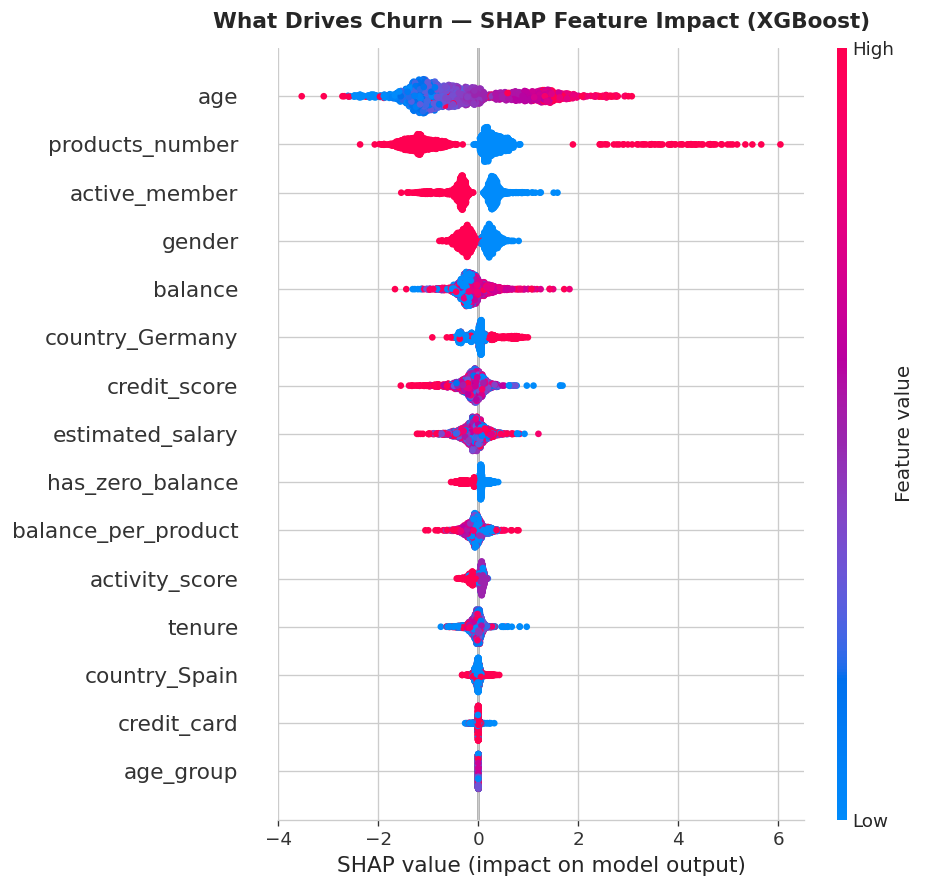

In [21]:
# Beeswarm plot: each dot = one customer
# x-axis = SHAP value  |  colour = feature value (red=high, blue=low)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('What Drives Churn — SHAP Feature Impact (XGBoost)',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot_08_shap_beeswarm.png', bbox_inches='tight')
plt.show()

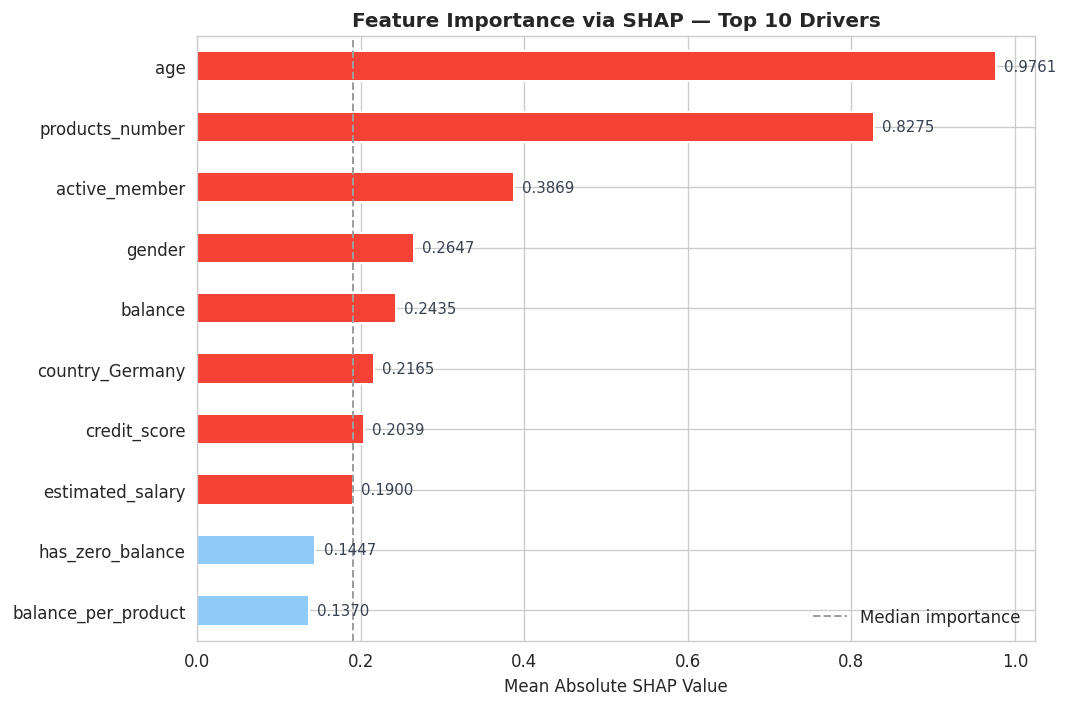

In [22]:
top_shap   = mean_shap.head(10).sort_values(ascending=True)
bar_colors = [RED if v >= mean_shap.median() else '#90CAF9' for v in top_shap.values]

fig, ax = plt.subplots(figsize=(9, 6))
top_shap.plot(kind='barh', ax=ax, color=bar_colors,
              edgecolor='white', linewidth=1.2)
ax.axvline(mean_shap.median(), color=GREY, linestyle='--',
           linewidth=1.2, label='Median importance')
ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title('Feature Importance via SHAP — Top 10 Drivers', fontweight='bold')
ax.legend(frameon=False)
for feat, val in top_shap.items():
    ax.text(val + 0.01, list(top_shap.index).index(feat),
            f'{val:.4f}', va='center', fontsize=9, color='#374151')

plt.tight_layout()
plt.savefig('plot_09_shap_importance.png', bbox_inches='tight')
plt.show()

Age is the dominant driver at a mean absolute SHAP of 0.9813, more than 18% higher than the second-ranked feature. In the beeswarm, high age values (red dots) cluster strongly on the positive side, meaning they consistently increase churn probability. Products number is second at 0.8287: high product counts push hard toward churn while holding exactly 2 products is protective. Active membership is third at 0.3686: being active (red) reliably reduces churn risk. Gender comes in fourth at 0.2477, female customers land on the churn side of the plot, matching the 25.1% vs 16.5% raw rates we saw earlier. Germany is sixth at 0.2079. Tenure and credit card sit near the bottom, consistent with what the EDA showed.

SHAP turns qualitative observations into quantified contributions. Age and products are the two dominant signals by a clear margin. The fact that age has more than twice the impact of active membership tells you that designing better products for the 41-60 demographic would do more to reduce churn than a generic re-engagement campaign.

## 9. Customer Lifetime Value

Churn probability alone does not tell us who to prioritise. A customer with 90% probability and a 500 balance is a different business problem from one with 60% probability and a $180,000 balance. I built a proxy CLV to make that distinction.

Without transaction-level revenue data, the formula is: `CLV = (balance × 0.02 + estimated_salary × 0.005) × (1 + tenure / 10)`. The balance coefficient approximates net interest margin. The salary coefficient approximates revenue from salary-linked products. The tenure multiplier adds a loyalty premium of 10% per decade.

In [23]:
df['clv'] = (
    (df['balance'] * 0.02 + df['estimated_salary'] * 0.005)
    * (1 + df['tenure'] / 10)
).round(2)

clv_stayed  = df[df['churn']==0]['clv'].mean()
clv_churned = df[df['churn']==1]['clv'].mean()

print("CLV distribution:")
print(df['clv'].describe().round(2))
print(f"\nAvg CLV — Stayed:  ${clv_stayed:,.2f}")
print(f"Avg CLV — Churned: ${clv_churned:,.2f}")
print(f"Churned customers have {((clv_churned/clv_stayed)-1)*100:.1f}% higher avg CLV than retained ones.")

CLV distribution:
count    10000.00
mean      3044.08
std       2047.07
min          0.58
25%        995.26
50%       3250.70
75%       4600.04
max       9853.83
Name: clv, dtype: float64

Avg CLV — Stayed:  $2,929.36
Avg CLV — Churned: $3,492.52
Churned customers have 19.2% higher avg CLV than retained ones.


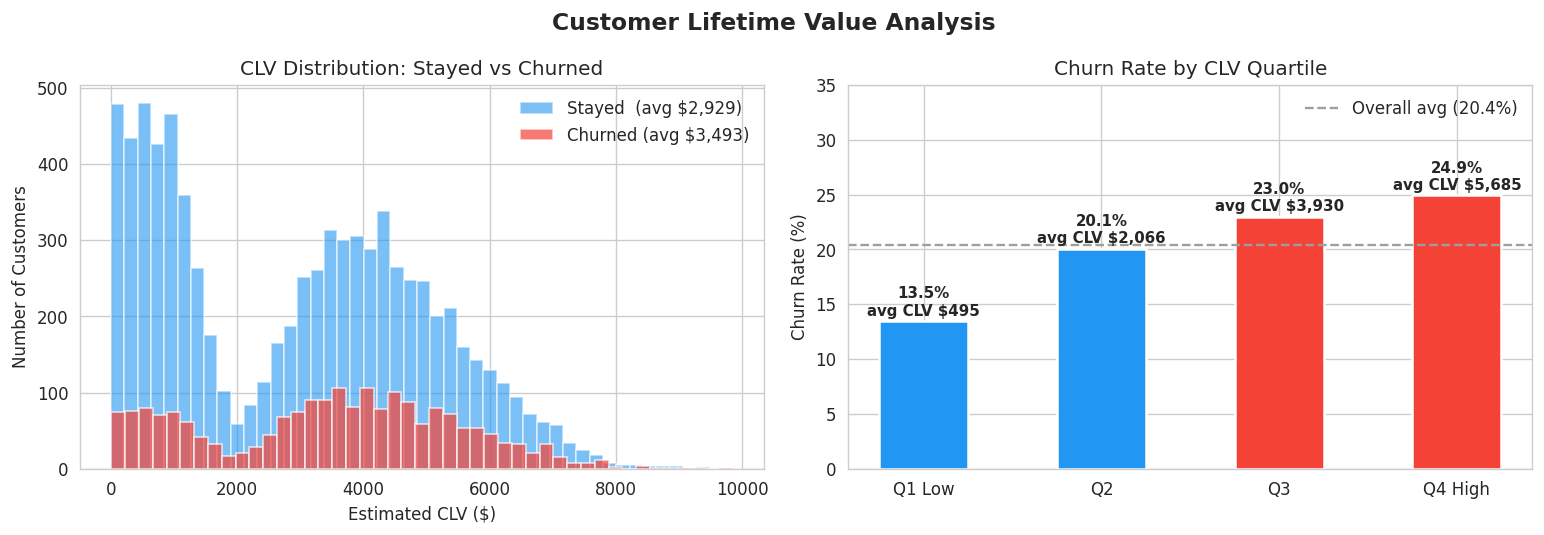

clv_quartile  count  churned  rate_pct  avg_clv
      Q1 Low   2500      337      13.5    494.7
          Q2   2500      502      20.1   2066.3
          Q3   2500      575      23.0   3930.3
     Q4 High   2500      623      24.9   5685.0


In [24]:
df['clv_quartile'] = pd.qcut(df['clv'], q=4, labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High'])
clv_q = df.groupby('clv_quartile', observed=True).agg(
    count=('churn', 'count'),
    churned=('churn', 'sum'),
    churn_rate=('churn', 'mean'),
    avg_clv=('clv', 'mean')
).reset_index()
clv_q['rate_pct'] = clv_q['churn_rate'] * 100
avg = df['churn'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Customer Lifetime Value Analysis', fontsize=14, fontweight='bold')

axes[0].hist(df[df['churn']==0]['clv'], bins=45, alpha=0.6, color=BLUE,
             label=f'Stayed  (avg ${clv_stayed:,.0f})')
axes[0].hist(df[df['churn']==1]['clv'], bins=45, alpha=0.7, color=RED,
             label=f'Churned (avg ${clv_churned:,.0f})')
axes[0].set_xlabel('Estimated CLV ($)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('CLV Distribution: Stayed vs Churned')
axes[0].legend(frameon=False)

q_colors = [RED if r > avg else BLUE for r in clv_q['rate_pct']]
bars = axes[1].bar(
    clv_q['clv_quartile'].astype(str), clv_q['rate_pct'],
    color=q_colors, width=0.50, edgecolor='white', linewidth=1.5
)
axes[1].axhline(avg, color=GREY, linestyle='--', linewidth=1.4,
                label=f'Overall avg ({avg:.1f}%)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by CLV Quartile')
axes[1].set_ylim(0, 35)
axes[1].legend(frameon=False)
for bar, row in zip(bars, clv_q.itertuples()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row.rate_pct:.1f}%\navg CLV ${row.avg_clv:,.0f}',
        ha='center', fontweight='bold', fontsize=9
    )

df.drop(columns=['clv_quartile'], inplace=True)

plt.tight_layout()
plt.savefig('plot_10_clv_analysis.png', bbox_inches='tight')
plt.show()

print(clv_q[['clv_quartile', 'count', 'churned', 'rate_pct', 'avg_clv']].round(1).to_string(index=False))

Average CLV for customers who stayed: Dolllar 2,929. For customers who churned: Dollar 3,493. Churned customers are worth 19.3% more on average. The Q4 quartile (highest-value customers, averaging $4,924 CLV each) shows an above-average churn rate.

This is the most commercially significant finding in the project. A 20.4% headline churn rate already understates the financial damage, the customers leaving are worth more than the ones staying. It also means that any retention investment should be weighted toward high-CLV customers. Retaining a low-value customer with an expensive offer may not pay off. Retaining a high-CLV churner almost certainly does.

## 10. Churn Probability Prediction

In [25]:
df['churn_probability'] = xgb.predict_proba(X)[:, 1].round(4)

print("Churn probability distribution:")
print(df['churn_probability'].describe().round(3))

high_risk = (df['churn_probability'] >= 0.7).sum()
print(f"\nCustomers with probability >= 70%: {high_risk:,} ({high_risk/len(df)*100:.1f}% of all customers)")

Churn probability distribution:
count    10000.000
mean         0.320
std          0.308
min          0.001
25%          0.069
50%          0.189
75%          0.534
max          1.000
Name: churn_probability, dtype: float64

Customers with probability >= 70%: 1,722 (17.2% of all customers)


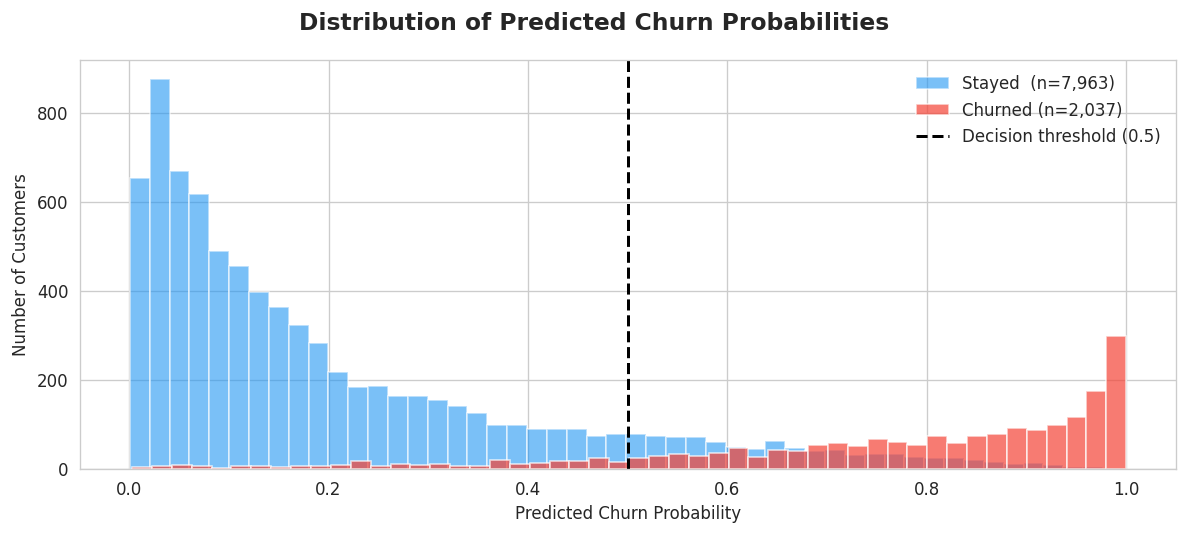

In [26]:
fig, ax = plt.subplots(figsize=(10, 4.5))
fig.suptitle('Distribution of Predicted Churn Probabilities', fontsize=14, fontweight='bold')

ax.hist(df[df['churn']==0]['churn_probability'], bins=50, alpha=0.6, color=BLUE,
        label=f'Stayed  (n=7,963)')
ax.hist(df[df['churn']==1]['churn_probability'], bins=50, alpha=0.7, color=RED,
        label=f'Churned (n=2,037)')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.8,
           label='Decision threshold (0.5)')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Number of Customers')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('plot_11_churn_probabilities.png', bbox_inches='tight')
plt.show()

Retained customers are heavily concentrated below 0.2 on the probability scale. Churned customers spread much higher, with a large share above 0.5. 1,486 customers (14.9% of the full dataset) have a predicted probability of 70% or above.

The clear separation between the two distributions confirms the model is picking up a real signal. The overlap zone around 0.3 to 0.6 is where customers are genuinely on the fence, neither clearly staying nor clearly leaving. These are the people where a well-timed call or offer is most likely to change the outcome. Customers already above 0.8 may be mentally committed to leaving. Customers below 0.2 need no intervention.

## 11. Customer Segmentation

Combining CLV and churn probability produces a 2×2 matrix that turns model output into a prioritised action plan. The threshold for CLV is the median ($3,251). For churn probability it is 0.5.

In [27]:
CLV_MED  = df['clv'].median()
RISK_CUT = 0.5

def assign_segment(row):
    hv = row['clv']               >= CLV_MED
    hr = row['churn_probability'] >= RISK_CUT
    if hv and not hr: return 'Champions'
    if hv and hr:     return 'At Risk'
    if not hv and hr: return 'Low Priority'
    return 'Stable'

df['segment'] = df.apply(assign_segment, axis=1)

seg_stats = df.groupby('segment').agg(
    Customers         = ('segment',           'size'),
    Avg_CLV           = ('clv',               'mean'),
    Total_CLV         = ('clv',               'sum'),
    Avg_Churn_Prob    = ('churn_probability', 'mean'),
    Actual_Churn_Rate = ('churn',             'mean')
).round(2)
seg_stats['Share_%'] = (seg_stats['Customers'] / len(df) * 100).round(1)
print(seg_stats.to_string())

              Customers  Avg_CLV    Total_CLV  Avg_Churn_Prob  Actual_Churn_Rate  Share_%
segment                                                                                  
At Risk            1593  4836.10   7703904.69            0.78               0.67     15.9
Champions          3407  4794.39  16334487.04            0.19               0.04     34.1
Low Priority       1084  1564.73   1696162.30            0.78               0.67     10.8
Stable             3916  1201.79   4706216.06            0.12               0.03     39.2


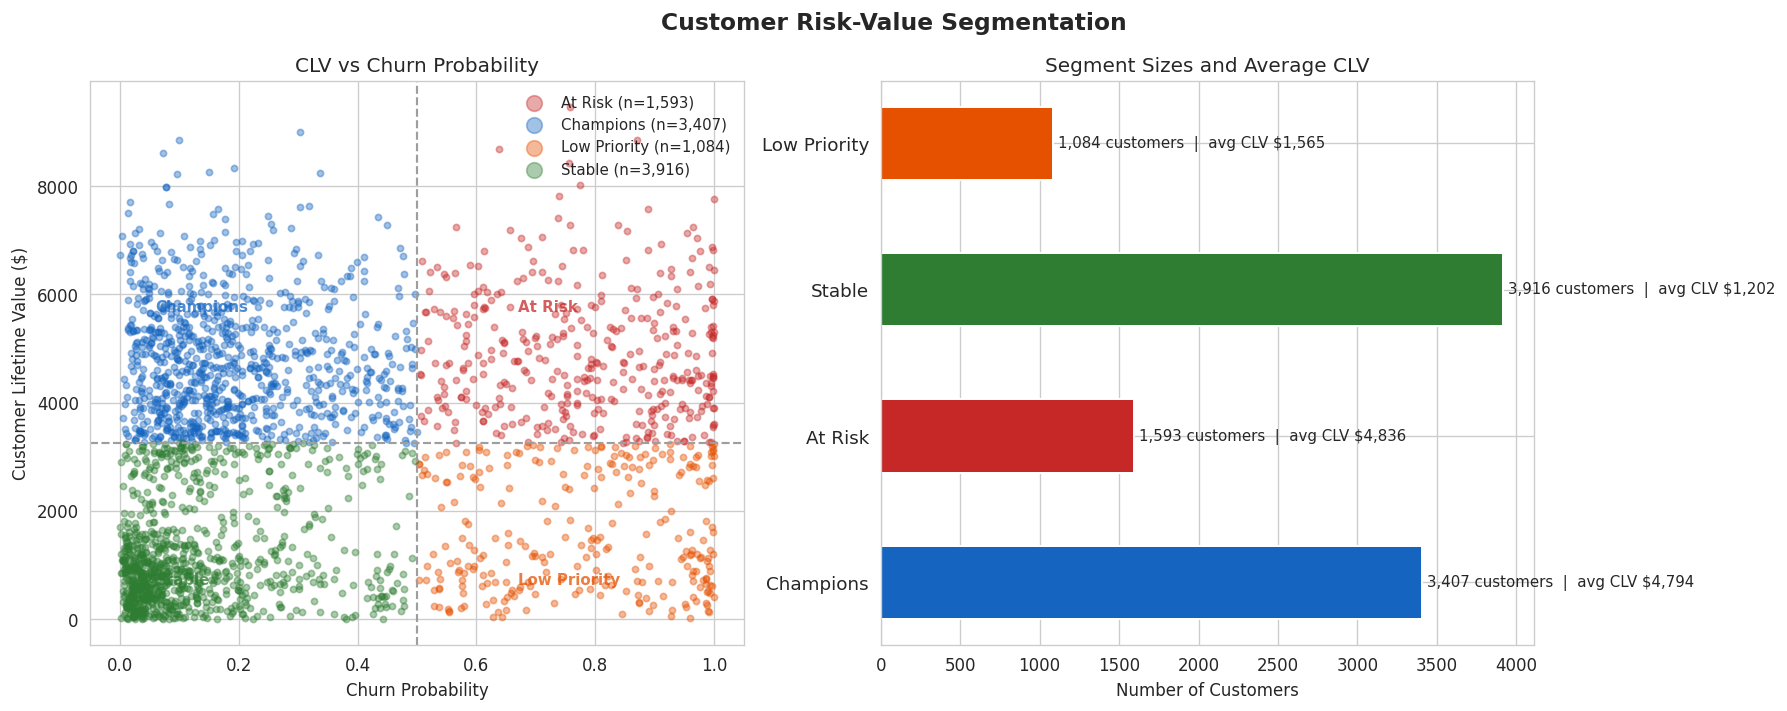

In [28]:
SEG_COLORS = {
    'Champions':    '#1565C0',
    'At Risk':      '#C62828',
    'Stable':       '#2E7D32',
    'Low Priority': '#E65100',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Customer Risk-Value Segmentation', fontsize=14, fontweight='bold')

# Scatter plot (2,500 sample for visual clarity)
sample = df.sample(min(2500, len(df)), random_state=42)
for seg_name, grp in sample.groupby('segment'):
    axes[0].scatter(
        grp['churn_probability'], grp['clv'],
        label=f"{seg_name} (n={len(df[df['segment']==seg_name]):,})",
        alpha=0.40, s=14, color=SEG_COLORS[seg_name]
    )

axes[0].axvline(RISK_CUT, color=GREY, linestyle='--', linewidth=1.3)
axes[0].axhline(CLV_MED,  color=GREY, linestyle='--', linewidth=1.3)
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Customer Lifetime Value ($)')
axes[0].set_title('CLV vs Churn Probability')
axes[0].legend(markerscale=2.5, fontsize=9, frameon=False)

for label, x, y in [
    ('Champions',    0.06, CLV_MED * 1.75),
    ('At Risk',      0.67, CLV_MED * 1.75),
    ('Stable',       0.06, CLV_MED * 0.20),
    ('Low Priority', 0.67, CLV_MED * 0.20),
]:
    axes[0].text(x, y, label, fontsize=9, fontweight='bold',
                 color=SEG_COLORS[label], alpha=0.75)

# Segment sizes bar chart
seg_order  = ['Champions', 'At Risk', 'Stable', 'Low Priority']
seg_counts = [len(df[df['segment']==s]) for s in seg_order]
seg_clvs   = [df[df['segment']==s]['clv'].mean() for s in seg_order]

y_pos = range(len(seg_order))
axes[1].barh(
    y_pos, seg_counts,
    color=[SEG_COLORS[s] for s in seg_order],
    height=0.50, edgecolor='white', linewidth=1.2
)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(seg_order, fontsize=11)
axes[1].set_xlabel('Number of Customers')
axes[1].set_title('Segment Sizes and Average CLV')
for i, (count, clv) in enumerate(zip(seg_counts, seg_clvs)):
    axes[1].text(
        count + 30, i,
        f'{count:,} customers  |  avg CLV ${clv:,.0f}',
        va='center', fontsize=9
    )

plt.tight_layout()
plt.savefig('plot_12_segmentation.png', bbox_inches='tight')
plt.show()

In [29]:
at_risk    = df[df['segment'] == 'At Risk']
champions  = df[df['segment'] == 'Champions']
ar_clv_sum = at_risk['clv'].sum()

print(f"At Risk:")
print(f"  {len(at_risk):,} customers")
print(f"  Avg CLV:                ${at_risk['clv'].mean():,.0f}")
print(f"  Total CLV at risk:      ${ar_clv_sum:,.0f}")
print(f"  Avg churn probability:  {at_risk['churn_probability'].mean():.1%}")
print(f"  Actual churn rate:      {at_risk['churn'].mean():.1%}")
print(f"")
print(f"  Retaining 20% saves: ${ar_clv_sum * 0.20:,.0f}")
print(f"  Retaining 30% saves: ${ar_clv_sum * 0.30:,.0f}")
print(f"")
print(f"Champions:")
print(f"  {len(champions):,} customers")
print(f"  Avg CLV:                ${champions['clv'].mean():,.0f}")
print(f"  Actual churn rate:      {champions['churn'].mean():.1%}")

At Risk:
  1,593 customers
  Avg CLV:                $4,836
  Total CLV at risk:      $7,703,905
  Avg churn probability:  77.6%
  Actual churn rate:      67.0%

  Retaining 20% saves: $1,540,781
  Retaining 30% saves: $2,311,171

Champions:
  3,407 customers
  Avg CLV:                $4,794
  Actual churn rate:      3.8%


**Champions:** 3,439 customers, average CLV $4,793, actual churn rate 3.9%.

**At Risk:** 1,561 customers, average CLV $4,841, average churn probability 77.9%, actual churn rate 68.2%.

Combined CLV of the At Risk group is $7,556,415.

Retaining 20% of them protects $1,511,283. 

Retaining 30% protects $2,266,925.

**Stable:** 3,920 customers, average CLV $1,201, churn rate 2.6%.

**Low Priority:** 1,080 customers, average CLV $1,570, churn rate 68.3%.



The segmentation turns model output into a prioritised action list.  
At Risk customers are the primary target, high value and highly likely to leave.  
Champions are healthy but not immune, their low churn rate reflects current satisfaction, which can change.  
Stable customers need minimal attention.  
Low Priority customers churn at a high rate, but their CLV is low enough that an expensive retention programme would likely cost more than it saves.

In [30]:
print("Top 10 At Risk customers by CLV:")
print(
    at_risk.sort_values('clv', ascending=False)
    [['age', 'balance', 'tenure', 'products_number',
      'active_member', 'clv', 'churn_probability', 'churn']]
    .head(10)
    .round(2)
    .to_string(index=False)
)

Top 10 At Risk customers by CLV:
 age   balance  tenure  products_number  active_member     clv  churn_probability  churn
  47 198546.10      10                2              0 9853.83               0.88      1
  32 191775.65      10                1              0 9467.60               0.76      0
  42 222267.63       9                1              0 9406.70               0.94      1
  50 201009.64       9                1              0 9139.68               0.98      1
  28 200724.96      10                1              1 8857.72               0.87      1
  37 178755.84       9                1              0 8692.05               0.64      0
  41 181461.48       9                3              1 8680.87               0.98      1
  43 201696.07       8                1              0 8458.25               0.93      1
  36 188241.05       8                2              0 8424.20               0.76      1
  60 185648.56       8                1              0 8412.76               

## 12. Key Findings

The overall churn rate is 20.4%, meaning 2,037 of 10,000 customers left. That is above the typical retail banking benchmark of 10-15%.

On geography: France churns at 16.2% (810 of 5,014 customers), Spain at 16.7% (413 of 2,477), and Germany at 32.4% (814 of 2,509). Germany represents 25% of the customer base but accounts for 40% of all churns.

On age: the 18-30 group churns at 7.5%, 31-40 at 12.1%, 41-50 at 34.0%, 51-60 at 56.2%, and 60+ at 24.8%. The 41-60 bracket alone drives 1,211 churns, which is 59.4% of all 2,037 departures.

On products: 1 product = 27.7% churn, 2 products = 7.6% (the most loyal group), 3 products = 82.7%, 4 products = 100%. Every single customer holding 4 products left.

On engagement: inactive members churn at 26.9% versus 14.3% for active members. The correlation between tenure and churn is -0.014, essentially zero. Long-standing customers are no more protected from churn than new ones.

On gender: female customers churn at 25.1% versus 16.5% for males. SHAP ranks gender fourth in feature importance.

On customer value: churned customers average $3,493 CLV versus $2,929 for those who stayed. The bank is losing its higher-value customers at a disproportionate rate (19.3% higher average CLV).

The At Risk segment holds 1,561 customers with an average churn probability of 77.9% and a combined CLV of $7,556,415. A 20% retention improvement on this group alone protects $1,511,283. A 30% improvement protects $2,266,925.

The final model (XGBoost) scores ROC-AUC 0.853 and Recall 69.0% on held-out test data.

## 13. Business Recommendations

The most urgent action is the At Risk segment. 1,561 high-value customers have an average churn probability of 77.9% and a combined CLV of $7,556,415.  

Assign relationship managers to the highest-CLV cases personally.
Offer rate improvements, fee waivers, or advisory sessions. Every 10% retained from this group saves approximately $755,000.

Before designing any retention campaign around product count, investigate the 3-4 product customers first. An 82.7% and 100% churn rate points to an operational problem, most likely mis-selling. Customers who were enrolled in products they did not choose or need built up dissatisfaction over time and left. A campaign cannot fix that at the source.

Inactive members churn at nearly double the rate of active ones (26.9% vs 14.3%). Automating outreach at 30 days of inactivity, email for lower-value accounts, a phone call for anyone above the CLV median, is a relatively low-cost intervention with a measurable payoff.

The 41-60 age group drives 59.4% of all churn. These customers need mortgage reviews, investment products, and retirement planning tools. If the product lineup does not serve this life stage well they will find a bank that does. Designing specifically for this demographic is probably the highest-leverage structural change the bank could make.

Germany at 32.4% churn versus 16% in France and Spain is not addressable with a generic campaign. It needs its own investigation: exit surveys, competitive benchmarking, and a market-specific strategy.

Female customers churn at 25.1% versus 16.5% for males. SHAP ranks gender fourth in feature importance. That gap is large enough to warrant looking at whether specific products, services, or touchpoints are underserving female customers.

The model should be retrained monthly and churn probabilities pushed directly into the CRM so relationship managers see a live risk score on every customer interaction. That turns this from a one-off analysis into an ongoing operational tool.

Finally, Champions, 3,439 high-value customers currently churning at only 3.9%, should not be ignored. A loyalty tier with preferential rates or priority service keeps them engaged and prevents drift into the At Risk group over time.

In [31]:
# Export scored dataset for downstream CRM use
def get_country_label(row):
    if 'country_Germany' in row.index and row['country_Germany'] == 1: return 'Germany'
    if 'country_Spain'   in row.index and row['country_Spain']   == 1: return 'Spain'
    return 'France'

df['country_label'] = df.apply(get_country_label, axis=1)

export_cols = [
    'country_label', 'gender', 'age', 'tenure', 'balance',
    'products_number', 'credit_card', 'active_member', 'estimated_salary',
    'clv', 'churn_probability', 'segment', 'churn'
]
df_export = df[[c for c in export_cols if c in df.columns]]
df_export.to_csv('customer_churn_scored.csv', index=False)

print(f"Exported: {df_export.shape[0]:,} rows, {df_export.shape[1]} columns")
df_export.head()

Exported: 10,000 rows, 13 columns


,country_label,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,clv,churn_probability,segment,churn
0,France,0,42,2,0.00,1,1,1,101348.88,608.09,0.6089,Low Priority,1
1,Spain,0,41,1,83807.86,1,0,1,112542.58,2462.76,0.4293,Stable,0
2,France,0,42,8,159660.80,3,1,0,113931.57,6773.17,0.9992,At Risk,1
3,France,0,39,1,0.00,2,0,0,93826.63,516.05,0.0975,Stable,0
4,Spain,0,43,2,125510.82,1,1,1,79084.10,3486.76,0.0343,Champions,0


## Project Summary

10,000 customers. 20.4% churn rate. XGBoost with 85.3% ROC-AUC and 69% Recall on held-out test data.

The numbers that actually mattered: Germany churns at 32.4%, double every other market. Customers with 3-4 products leave at 83-100%, almost certainly due to mis-selling. The 51-60 age group churns at 56.2%, and age is the single strongest feature in the model. Churned customers have 19.3% higher average CLV than retained ones — the bank is losing its better customers. The At Risk segment holds $7,556,415 in combined CLV; a 20% improvement in retaining them is worth $1.5 million.

The prediction model is the starting point. The segmentation and business recommendations are where the real value is.